In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df = pd.read_excel('Retail_Sales.xlsx')
df.head()

,Order_ID,Order_Date,Region,Product_Category,Sales,Profit,Discount
0,1001,08-12-2025,West,Sports,7267,7255,37
1,1002,29-06-2025,South,Furniture,19173,9124,21
2,1003,09-03-2025,West,Electronics,41732,12614,9
3,1004,03-02-2025,South,Clothing,26079,5652,22
4,1005,16-09-2025,North,Clothing,24381,8599,35


In [15]:
df.shape

(1000, 7)

In [16]:
df.dtypes

Order_ID            int64
Order_Date            str
Region                str
Product_Category      str
Sales               int64
Profit              int64
Discount            int64
dtype: object

In [17]:
df.isnull().sum()

Order_ID            0
Order_Date          0
Region              0
Product_Category    0
Sales               0
Profit              0
Discount            0
dtype: int64

In [18]:
df.describe()

,Order_ID,Sales,Profit,Discount
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,1500.500000,24792.518000,7400.472000,20.470000
std,288.819436,14139.455753,4364.770054,11.771562
min,1001.000000,1016.000000,116.000000,0.000000
25%,1250.750000,12307.250000,3573.500000,10.000000
50%,1500.500000,24622.000000,7367.000000,21.000000
75%,1750.250000,36996.500000,11305.750000,31.000000
max,2000.000000,49787.000000,14982.000000,40.000000


In [42]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)
df['Month'] = df['Order_Date'].dt.month
df['Month_Name'] = df['Order_Date'].dt.strftime('%b')

## Problem 1: Total Sales by Region

In [20]:
region_sales = df.groupby('Region')['Sales'].sum()
print(region_sales)
print('Highest:', region_sales.idxmax())
print('Lowest:', region_sales.idxmin())

Region
East     6165086
North    5485839
South    6520920
West     6620673
Name: Sales, dtype: int64
Highest: West
Lowest: North


In [43]:
df

,Order_ID,Order_Date,Region,Product_Category,Sales,Profit,Discount,Month,Month_Name
0,1001,2025-12-08,West,Sports,7267,7255,37,12,Dec
1,1002,2025-06-29,South,Furniture,19173,9124,21,6,Jun
2,1003,2025-03-09,West,Electronics,41732,12614,9,3,Mar
3,1004,2025-02-03,South,Clothing,26079,5652,22,2,Feb
4,1005,2025-09-16,North,Clothing,24381,8599,35,9,Sep
...,...,...,...,...,...,...,...,...,...
995,1996,2025-05-03,West,Grocery,31081,4377,25,5,May
996,1997,2025-07-28,West,Grocery,15259,12717,37,7,Jul
997,1998,2025-10-29,West,Furniture,32736,5254,3,10,Oct
998,1999,2025-09-06,East,Sports,26406,4157,14,9,Sep


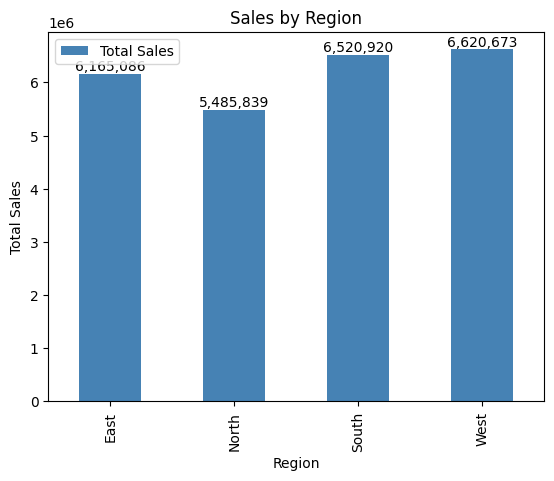

In [21]:
ax = region_sales.plot(kind='bar', label='Total Sales', color='steelblue')
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height(), f'{int(p.get_height()):,}', ha='center', va='bottom')
plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.legend()
plt.show()

## Problem 2: Total Profit by Product Category

In [22]:
cat_profit = df.groupby('Product_Category')['Profit'].sum()
print(cat_profit)
print('Most Profitable:', cat_profit.idxmax())

Product_Category
Clothing       1555492
Electronics    1514398
Furniture      1455494
Grocery        1263568
Sports         1611520
Name: Profit, dtype: int64
Most Profitable: Sports


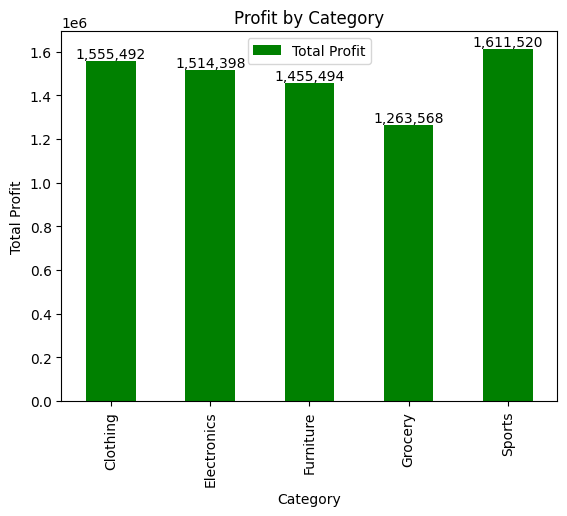

In [23]:
ax = cat_profit.plot(kind='bar', label='Total Profit', color='green')
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height(), f'{int(p.get_height()):,}', ha='center', va='bottom')
plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.legend()
plt.show()

## Problem 3: Average Discount by Region

In [24]:
region_discount = df.groupby('Region')['Discount'].mean()
print(region_discount)
print('Highest Discount Region:', region_discount.idxmax())

Region
East     20.031496
North    19.853081
South    21.904215
West     19.985401
Name: Discount, dtype: float64
Highest Discount Region: South


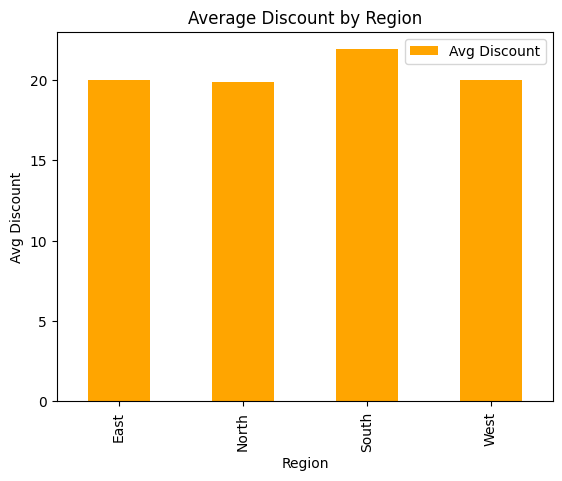

In [25]:
region_discount.plot(kind='bar', label='Avg Discount', color='orange')
plt.title('Average Discount by Region')
plt.xlabel('Region')
plt.ylabel('Avg Discount')
plt.legend()
plt.show()

## Problem 4: Top 10 Highest Sales Orders

In [26]:
top10 = df.nlargest(10, 'Sales')[['Order_ID', 'Region', 'Product_Category', 'Sales', 'Profit']]
print(top10)

     Order_ID Region Product_Category  Sales  Profit
628      1629   West        Furniture  49787    3636
740      1741  North      Electronics  49777   14046
375      1376  North        Furniture  49752   12065
299      1300   West           Sports  49735   14921
893      1894  North        Furniture  49628    8932
305      1306  North         Clothing  49543    7371
778      1779  South          Grocery  49382    2086
658      1659   West           Sports  49322    3773
710      1711  North          Grocery  49211    5552
477      1478   East        Furniture  49196    7625


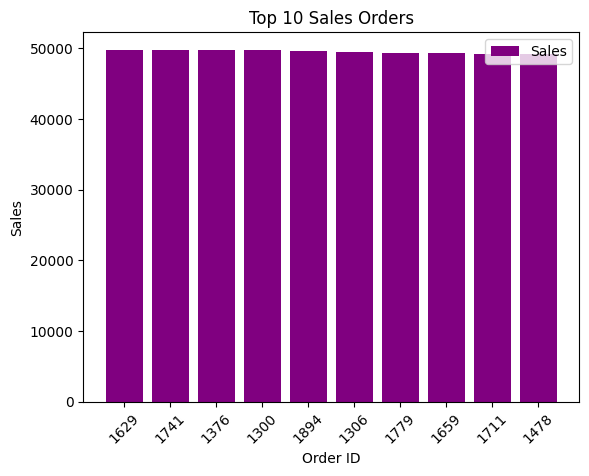

In [27]:
plt.bar(top10['Order_ID'].astype(str), top10['Sales'], label='Sales', color='purple')
plt.title('Top 10 Sales Orders')
plt.xlabel('Order ID')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.legend()
plt.show()

## Problem 5: Monthly Sales Trend

In [28]:
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_sales = df.groupby('Month_Name')['Sales'].sum().reindex(month_order)
print(monthly_sales)
print('Best Month:', monthly_sales.idxmax())

Month_Name
Jan    1779896
Feb    1676001
Mar    2407195
Apr    1840544
May    2131854
Jun    1825678
Jul    2218925
Aug    2328859
Sep    2368908
Oct    2069458
Nov    1966421
Dec    2178779
Name: Sales, dtype: int64
Best Month: Mar


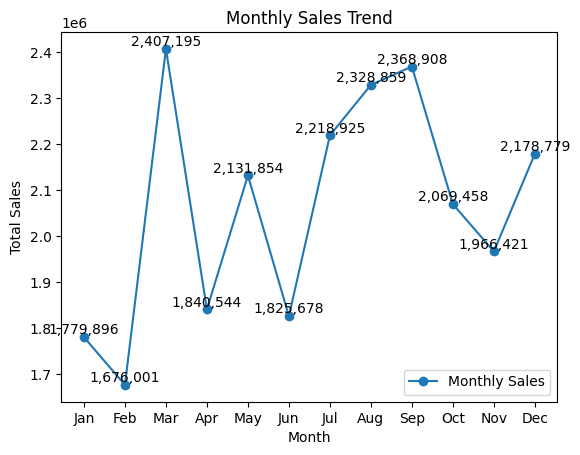

In [29]:
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', label='Monthly Sales')
for i, v in enumerate(monthly_sales.values):
    plt.text(i, v, f'{v:,}', ha='center', va='bottom')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.legend()
plt.show()

## Problem 6: Monthly Profit Trend

In [30]:
monthly_profit = df.groupby('Month_Name')['Profit'].sum().reindex(month_order)
print(monthly_profit)
print('Most Profitable Month:', monthly_profit.idxmax())

Month_Name
Jan    561500
Feb    575308
Mar    744206
Apr    533542
May    739495
Jun    505446
Jul    598990
Aug    660702
Sep    690128
Oct    519682
Nov    550897
Dec    720576
Name: Profit, dtype: int64
Most Profitable Month: Mar


In [41]:
df

,Order_ID,Order_Date,Region,Product_Category,Sales,Profit,Discount,Month,Month_Name
0,1001,2025-12-08,West,Sports,7267,7255,37,12,Dec
1,1002,2025-06-29,South,Furniture,19173,9124,21,6,Jun
2,1003,2025-03-09,West,Electronics,41732,12614,9,3,Mar
3,1004,2025-02-03,South,Clothing,26079,5652,22,2,Feb
4,1005,2025-09-16,North,Clothing,24381,8599,35,9,Sep
...,...,...,...,...,...,...,...,...,...
995,1996,2025-05-03,West,Grocery,31081,4377,25,5,May
996,1997,2025-07-28,West,Grocery,15259,12717,37,7,Jul
997,1998,2025-10-29,West,Furniture,32736,5254,3,10,Oct
998,1999,2025-09-06,East,Sports,26406,4157,14,9,Sep


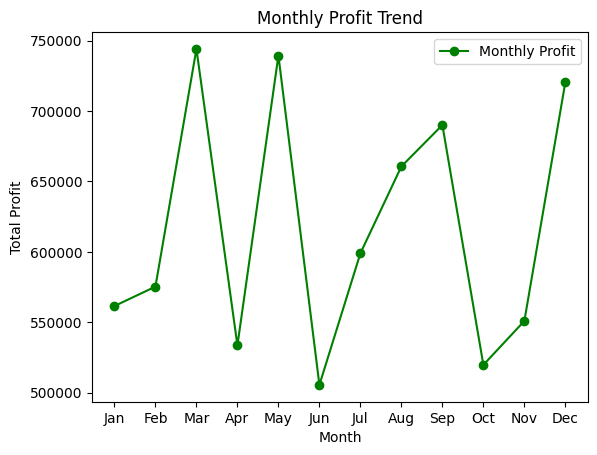

In [31]:
plt.plot(monthly_profit.index, monthly_profit.values, marker='o', label='Monthly Profit', color='green')
plt.title('Monthly Profit Trend')
plt.xlabel('Month')
plt.ylabel('Total Profit')
plt.legend()
plt.show()

## Problem 7: Relationship Between Sales and Profit

In [32]:
corr = df['Sales'].corr(df['Profit'])
print('Correlation between Sales and Profit:', corr)
print('Higher sales does not always mean higher profit')

Correlation between Sales and Profit: 0.018992677259515874
Higher sales does not always mean higher profit


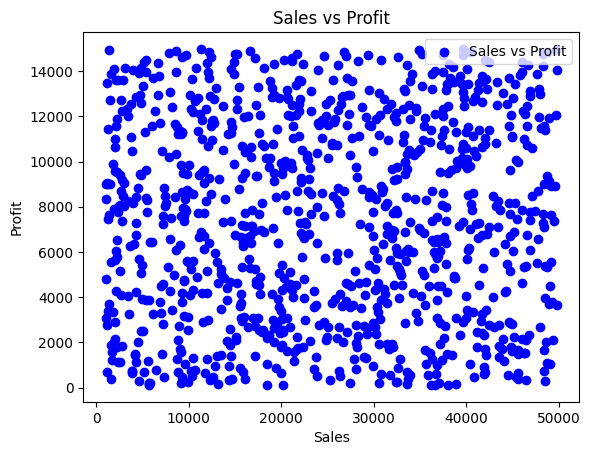

In [33]:
plt.scatter(df['Sales'], df['Profit'], color='blue', label='Sales vs Profit')
plt.title('Sales vs Profit')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.legend()
plt.show()

## Problem 8: Impact of Discount on Profit

In [34]:
corr2 = df['Discount'].corr(df['Profit'])
print('Correlation between Discount and Profit:', corr2)

Correlation between Discount and Profit: 0.04907699197641079


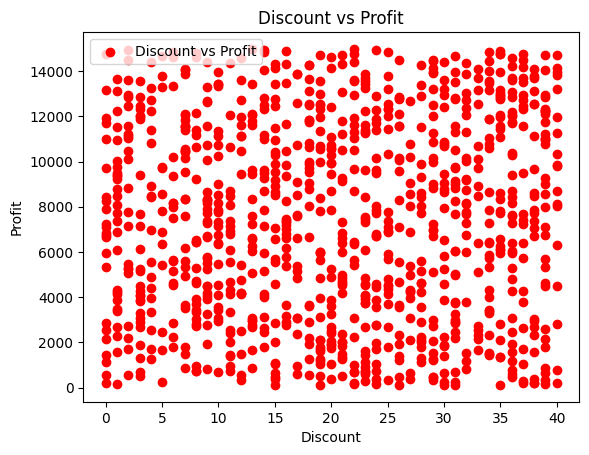

In [35]:
plt.scatter(df['Discount'], df['Profit'], color='red', label='Discount vs Profit')
plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.legend()
plt.show()

## Problem 9: Category-wise Sales Contribution

In [36]:
cat_sales = df.groupby('Product_Category')['Sales'].sum()
cat_pct = (cat_sales / cat_sales.sum()) * 100
print(cat_pct.round(2))

Product_Category
Clothing       18.47
Electronics    21.26
Furniture      19.83
Grocery        17.79
Sports         22.65
Name: Sales, dtype: float64


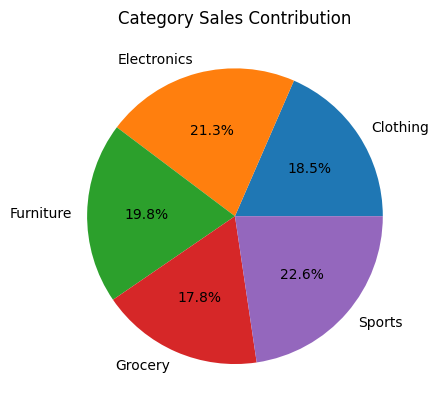

In [37]:
plt.pie(cat_sales, labels=cat_sales.index, autopct='%1.1f%%')
plt.title('Category Sales Contribution')
plt.show()

## Correlation Heatmap

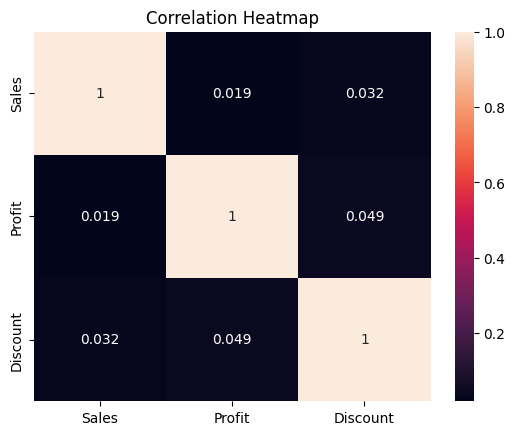

In [38]:
sns.heatmap(df[['Sales', 'Profit', 'Discount']].corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()

## Distribution of Sales and Profit

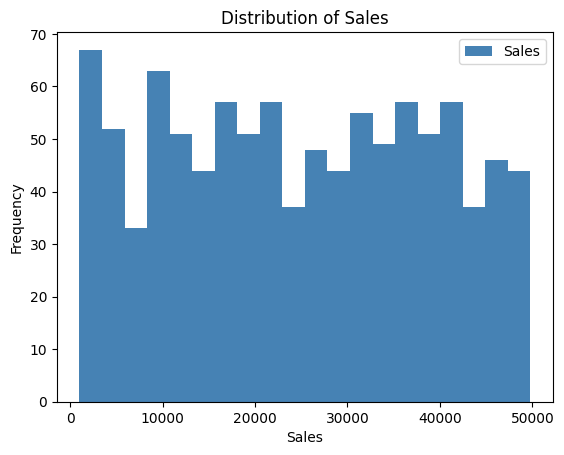

In [39]:
plt.hist(df['Sales'], bins=20, label='Sales', color='steelblue')
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.legend()
plt.show()

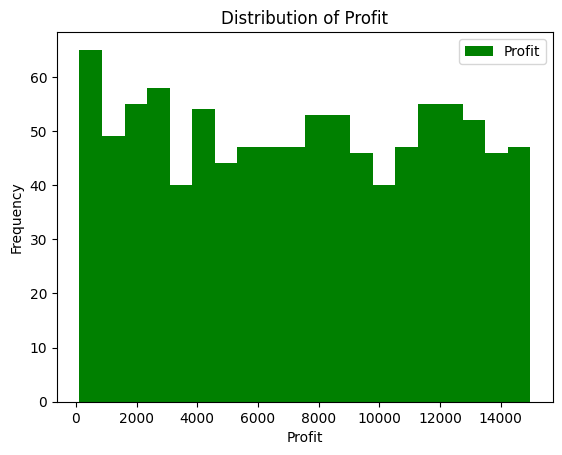

In [40]:
plt.hist(df['Profit'], bins=20, label='Profit', color='green')
plt.title('Distribution of Profit')
plt.xlabel('Profit')
plt.ylabel('Frequency')
plt.legend()
plt.show()